In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [25]:
api = wandb.Api()

In [26]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s14/distill-layerwise/run3/distill"

In [27]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    arr_training_sizes,
    arr_contamination_levels,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": {"$in": arr_training_sizes}},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["training_size", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        20,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",

    policy="basis-identity:pca--uncentered",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    
    lambda_task=0.0,
    lambda_kd=1.0,
    
    verbose=True,
)

summary

we have 320 runs
df.shape: (16, 12)


training_size contamination_level val_acc                 val_agreement  \
                                        mean       std count          mean   
0           0.10                0.00  0.7091  0.102533    20        0.7129   
1           0.10                0.25  0.6903  0.100341    20        0.6961   
2           0.10                0.50  0.6277  0.110568    20        0.6378   
3           0.10                0.75  0.5496  0.122109    20        0.5579   
4           0.25                0.00  0.7780  0.098628    20        0.7876   
5           0.25                0.25  0.7653  0.099775    20        0.7736   
6           0.25                0.50  0.7113  0.109848    20        0.7211   
7           0.25                0.75  0.6264  0.119701    20        0.6373   
8           0.50                0.00  0.8169  0.088785    20        0.8229   
9           0.50                0.25  0.8007  0.089356    20        0.8090   
10          0.50                0.50  0.7477  0.109980    20        0.7561   
11          0.50                0.75  0.6551  0.123555    20        0.6711   
12          1.00                0.00  0.8542  0.078721    20        0.8646   
13          1.00                0.25  0.8344  0.087107    20        0.8460   
14          1.00                0.50  0.7883  0.101867    20        0.8048   
15          1.00                0.75  0.7207  0.125827    20        0.7357   

                   val_agreement_on_teacher_correct                  \
         std count                             mean       std count   
0   0.102196    20                           0.6650  0.121945    20   
1   0.096961    20                           0.6448  0.119085    20   
2   0.109279    20                           0.5876  0.122750    20   
3   0.123924    20                           0.5098  0.129600    20   
4   0.096456    20                           0.7335  0.120299    20   
5   0.096724    20                           0.7175  0.120591    20   
6   0.104238    20                           0.6663  0.126041    20   
7   0.114385    20                           0.5862  0.127062    20   
8   0.084466    20                           0.7683  0.111343    20   
9   0.083551    20                           0.7519  0.110416    20   
10  0.104596    20                           0.7017  0.124211    20   
11  0.112234    20                           0.6160  0.130647    20   
12  0.063435    20                           0.8043  0.097832    20   
13  0.072733    20                           0.7832  0.106097    20   
14  0.086537    20                           0.7436  0.114870    20   
15  0.110612    20                           0.6790  0.134272    20   

   teacher_acc  
          mean  
0       0.8677  
1       0.8608  
2       0.8556  
3       0.8498  
4       0.8677  
5       0.8608  
6       0.8556  
7       0.8497  
8       0.8677  
9       0.8608  
10      0.8556  
11      0.8498  
12      0.8677  
13      0.8608  
14      0.8556  
15      0.8498

In [14]:
read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",

    policy="basis-identity:prca-sortabs--uncentered",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    
    lambda_task=0.0,
    lambda_kd=1.0,
    
    verbose=True,
)


we have 320 runs
df.shape: (16, 12)


training_size contamination_level val_acc                 val_agreement  \
                                        mean       std count          mean   
0           0.10                0.00  0.6873  0.104624    20        0.6942   
1           0.10                0.25  0.6840  0.101097    20        0.6931   
2           0.10                0.50  0.6274  0.113840    20        0.6367   
3           0.10                0.75  0.5364  0.114529    20        0.5451   
4           0.25                0.00  0.7800  0.096092    20        0.7873   
5           0.25                0.25  0.7674  0.094542    20        0.7736   
6           0.25                0.50  0.7176  0.114385    20        0.7264   
7           0.25                0.75  0.6402  0.118687    20        0.6522   
8           0.50                0.00  0.8173  0.086432    20        0.8297   
9           0.50                0.25  0.7979  0.092458    20        0.8105   
10          0.50                0.50  0.7474  0.105531    20        0.7638   
11          0.50                0.75  0.6632  0.125152    20        0.6767   
12          1.00                0.00  0.8513  0.078091    20        0.8659   
13          1.00                0.25  0.8354  0.082004    20        0.8457   
14          1.00                0.50  0.7888  0.098392    20        0.8080   
15          1.00                0.75  0.7257  0.118324    20        0.7421   

                   val_agreement_on_teacher_correct                  \
         std count                             mean       std count   
0   0.099814    20                           0.6452  0.120484    20   
1   0.099697    20                           0.6411  0.118482    20   
2   0.107590    20                           0.5860  0.125494    20   
3   0.116179    20                           0.4980  0.123594    20   
4   0.093912    20                           0.7338  0.118689    20   
5   0.094257    20                           0.7184  0.117952    20   
6   0.111016    20                           0.6730  0.130000    20   
7   0.112747    20                           0.5989  0.129047    20   
8   0.074991    20                           0.7708  0.105212    20   
9   0.087563    20                           0.7507  0.113968    20   
10  0.096210    20                           0.7035  0.121629    20   
11  0.118502    20                           0.6231  0.133794    20   
12  0.061406    20                           0.8039  0.098073    20   
13  0.065129    20                           0.7830  0.101373    20   
14  0.086509    20                           0.7449  0.115368    20   
15  0.105789    20                           0.6832  0.128851    20   

   teacher_acc  
          mean  
0       0.8677  
1       0.8608  
2       0.8556  
3       0.8498  
4       0.8677  
5       0.8608  
6       0.8556  
7       0.8498  
8       0.8677  
9       0.8608  
10      0.8556  
11      0.8497  
12      0.8677  
13      0.8608  
14      0.8556  
15      0.8498

In [28]:
def read_data_baseline(
    teacher,
    student,
    lambda_task,
    lambda_kd,
    training_size,
    arr_contamination_levels,
    verbose=False,
    
):
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP + "-baselinerun"},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": "basis-identity:random--uncentered"},
            {"config.training_size": training_size},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    for run in runs:
        seed = run.config["seed"]
        
        if "arr_metrics" not in run.summary:
            count += 1
            print("failed run: dataset=", run.config["dataset"])
            continue
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]

        assert run.config["lambda_layer"] is not None

        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    if count > 0:
        print(f"We have {count} failed runs")
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["training_size", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        20,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

read_data_baseline(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    training_size=1.0,
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    lambda_task=0.0,
    lambda_kd=1.0
)

training_size contamination_level val_acc                 val_agreement  \
                                       mean       std count          mean   
0             1                0.00  0.8021  0.089972    20        0.7972   
1             1                0.25  0.7572  0.107958    20        0.7562   
2             1                0.50  0.6460  0.105567    20        0.6553   
3             1                0.75  0.5152  0.115897    20        0.5245   

                  val_agreement_on_teacher_correct                 teacher_acc  
        std count                             mean       std count        mean  
0  0.089521    20                           0.7496  0.112223    20      0.8677  
1  0.103226    20                           0.7075  0.123816    20      0.8608  
2  0.097543    20                           0.6057  0.117436    20      0.8556  
3  0.106583    20                           0.4779  0.121922    20      0.8497

# Comparison on `training-size` and `contamination-level`

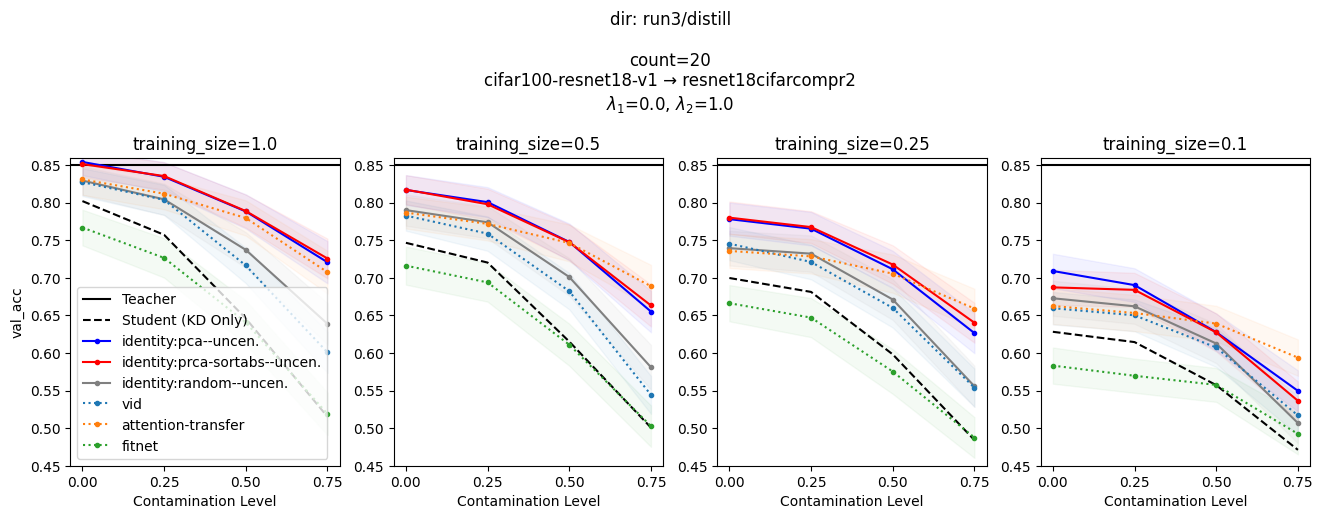

In [29]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    return policy \
        .replace("basis-identity", "identity") \
        .replace("uncentered", "uncen.")

    
    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner" or policy == "fitnetinvidbnrelu":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher, student, policies, 
    arr_training_sizes,
    arr_contamination_levels,
    show_legend=True,
    include_baseline=True
):
        
    lambda_kd = 1.0
    lambda_task = 0.0

    
        

    col = "val_acc"
    
    ncols = len(arr_training_sizes)
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])
    
    for tix, training_size in enumerate(arr_training_sizes):
        plt.subplot(nrows, ncols, tix+1)
        plt.title(f"training_size={training_size}")
        
        for pix, policy in enumerate(policies):
            df = read_data(
                teacher=teacher,
                student=student,
                policy=policy,
                
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,

                arr_training_sizes=[training_size],
                arr_contamination_levels=arr_contamination_levels,
                verbose=False
            )
            
            ticks = df["contamination_level"]

            
            # visualize baseline
            if pix == 0:

                plt.axhline(
                    df["teacher_acc"].values[-1],
                    ls="-",
                    color="k",
                    label="Teacher"
                )
                
                if include_baseline:
                    df_baseline = read_data_baseline(
                        teacher=teacher,
                        student=student,

                        lambda_task=lambda_task,
                        lambda_kd=lambda_kd,

                        training_size=training_size,
                        arr_contamination_levels=arr_contamination_levels,
                    )
                    plt.plot(
                        ticks,
                        df_baseline[col]["mean"],
                        ls="--",
                        color="k",
                        label="Student (KD Only)"
                    )
                plt.ylim(bottom=0.45, top=df["teacher_acc"].values[-1] + 0.01)
#                 plt.axhline(0.2, ls="--", color="lightgray")

            # here, we take the first value.
            # the query function already checks that the value is expected
            count = df[col]["count"].values[-1]

            mean = df[col]["mean"]
            stderr = df[col]["std"] / (count ** 0.5)

            plt.plot(
                ticks,
                mean,
                marker=".",
                label=alias(policy),
                ls=ls(policy),
                color=color(policy)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.05,
                color=plt.gca().lines[-1].get_color()
            )

        plt.xlabel("Contamination Level")
        plt.xticks(ticks)
        if tix==0:
            plt.ylabel(col)

            plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"count={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    policies = [ 
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ],
    include_baseline=True
) 

In [8]:
# viz_distillation(
#     teacher = "cifar100-resnet18-v1",
#     student="resnet18cifarcompr4",
#     arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
#     arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
#     policies = [ 
#         "basis-identity:pca--uncentered",
#         "basis-identity:prca-sortabs--uncentered",
#         "basis-identity:random--uncentered",
#         "vid",
#     ],
#     include_baseline=False
# ) 

# Analysis Fitnet Level

In [9]:
# viz_distillation(
#     teacher = "cifar100-resnet18-v1",
#     student="resnet18cifarcompr2",
#     arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
#     arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
#     policies = [ 
#         "fitnet",
#         "vid",
#         "fitnet-2l",
#         "fitnet-3l",
#     ],
# ) 

# Summary (to be written)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3$ is set according to the hyperparameter optimization with `contamination-level=0.5` and `training-size=1.0`.

*Aims:* 
- investigate the benefit of using PRCA when varying these aspects:
    - the quality of data
    - the quantity of data

    - the size of the student model

*Conclusions:*
- When the quality of the training data drops, PRCA provides slightly better distilled models.Howoever, the difference between PRCA and PCA (the 2nd best) is very small
- We do not seem to see any difference between PRCA and PCA when we varying the quantity of the training data and the size of the student model.
- When `contamination=0.75`, `attention-transfer` becomes very good. 



*Further Refinement*: 
- Currently, $\lambda_3$ is chosen per policy using only the clean data. Perhaps, it might be better to tune it per policy and contamination level. 
  - The reason is that the higher contamination, the more layer regularization required
      - One way to see this is that running `pca` for those contamination values.
          - Expected: for each contamination value, the accuracy curve peaks at different $\lambda_3$.
          - *Result*: not so, the global trend of the accuracy doesn't seem to change much when varying the $\lambda_3$.